### 💡 Nota de Configuración de Interfaz: Optimización del Despliegue Visual (Scroll Off)

**Aclaración Metodológica:** La siguiente celda *no forma parte del núcleo algorítmico, ni de las exigencias procedimentales o arquitectónicas de la Fase 3* (como sí lo son el encapsulamiento POO, la herencia o la recursividad). 

Se incorpora exclusivamente como una **herramienta técnica de soporte para la visualización expandida del notebook**. Su objetivo es forzar la inyección de estilos CSS avanzados con reglas de máxima prioridad (`!important`) directamente sobre el DOM del entorno. Esto desactiva el colapso automático de celdas (*output scrolling*) tanto en estructuras clásicas (`.output_wrapper`) como en contenedores modernos de JupyterLab (`.jp-OutputArea-child` y `.jp-Cell-outputArea`). 

De este modo, se garantiza que el equipo evaluador pueda auditar la totalidad de los reportes tabulares, los extensos diagnósticos estadísticos de calidad y las trazas completas del pipeline de arriba a abajo de forma continua, transparente y fluida en la pantalla, eliminando barras de desplazamiento incómodas.

In [1]:
from IPython.display import display, HTML

# Inyección CSS con esteroides para anular cualquier scroll o max-height heredado
display(HTML("""
<style>
    /* Jupyter Notebook Clásico */
    .output_wrapper, .output { height: auto !important; max-height: none !important; }
    .output_scroll { height: auto !important; max-height: none !important; }
    
    /* JupyterLab / Antigravity moderno */
    .jp-OutputArea-child, .jp-OutputArea-output { height: auto !important; max-height: none !important; overflow: visible !important; }
    .jp-Cell-outputArea { max-height: none !important; overflow: visible !important; }
    
    /* Contenedores generales de scroll ocultos */
    .output_subarea { max-height: none !important; overflow: visible !important; }
</style>
"""))

# Avance Fase 3 — Núcleo Algorítmico y Programación Orientada a Objetos (POO)
**Curso:** MCDI500 — Programación para la Ciencia de Datos  
**Programa:** Magíster en Ciencia de Datos e IA, UNAB  
**Grupo:** Grupo 6  

## 1. Justificación del Cambio de Paradigma
En la Fase 2, el preprocesamiento del dataset se resolvió mediante un enfoque procedimental/funcional. Aunque fue eficiente, obligaba a transferir constantemente el estado del DataFrame entre celdas globales de ejecución.

En esta Fase 3, migramos formalmente hacia la **Programación Orientada a Objetos (POO)** para lograr:
1. **Encapsulamiento del Estado:** El conjunto de datos clínico de diabetes se almacena de forma segura en un atributo interno del objeto (`self.df`), protegiéndolo de modificaciones accidentales desde el exterior.
2. **Modularidad mediante Métodos:** Cada etapa de transformación se convierte en un método de instancia que muta el estado interno y retorna la propia instancia (`self`), habilitando un flujo elegante de ejecución encadenada (*Method Chaining*).

## 2. Configuración del Entorno e Importación Modular

Para garantizar la reproducibilidad técnica y dar cumplimiento al principio de paridad de entornos, procedemos a inicializar el Kernel científico. En este bloque se importan las herramientas de infraestructura de Python y se añade la ruta del repositorio para invocar nuestra caja de herramientas en `src/utils.py`.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
import re
import numpy as np
import pandas as pd
from pathlib import Path

import time
import tracemalloc

# Permitir la importación de módulos personalizados desde la carpeta raíz del repositorio
sys.path.append('../')

# Importar el pipeline orientado a objetos y el componente recursivo desde utils
from src.utils import (
    PreprocesadorDiabetes,
    VisualizadorDiabetes,
    auditar_carpetas_recursivo
)

## 3. Orquestación del Pipeline de Preprocesamiento Clínico

Haciendo uso de la clase base unificada `PreprocesadorDiabetes`, invocamos los métodos de transformación de forma encadenada mediante el patrón *Method Chaining*. El pipeline resolverá de manera secuencial la carga tolerante a fallos, el diagnóstico estático de calidad, la exclusión explícita de la columna `SkinThickness` debido a su degradación sintáctica, el casting con expresiones regulares de `BloodPressure`, la imputación por mediana, la creación de variables derivadas, el escalamiento estandarizado y la validación final mediante aserciones estrictas (`assert`).

In [3]:
# 1. Definimos las rutas relativas a los activos de datos (Sincronizadas con F2)
RUTA_ENTRADA_F2 = Path("../data/processed/diabetes_processed.csv")
RUTA_DESTINO_F3 = Path("../data/processed/diabetes_fase3_final.csv")

# Listas de control técnico para imputación y escalamiento
COLS_IMPUTAR = ['Glucose', 'BloodPressure', 'BMI', 'Insulin', 'Age']
COLS_ESCALAR = ['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# 2. Instanciamos la subclase especializada
pipeline = PreprocesadorDiabetes(RUTA_ENTRADA_F2)

# 3. Ejecución encadenada limpia (Incorporando el método POLIMÓRFICO)
df_clinico_final = (pipeline
                    .cargar_datos()
                    .explorar_dataset()
                    .procesar_especifico()  # <-- AQUÍ OPERA EL POLIMORFISMO (Elimina SkinThickness)
                    .eliminar_duplicados()
                    .validar_dataset_final() # <-- Ahora pasará con 0 NaN de forma impecable
                    .resumen_comparativo()
                    .exportar_dataset(RUTA_DESTINO_F3)
                    .obtener_dataframe())

# 4. Despliegue de las primeras filas de la matriz final purificada
df_clinico_final.head()

[OK] Ingesta exitosa. Dimensiones: 2000 filas × 16 columnas.
[1] TIPOS DE DATOS
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
AgeGroup                        str
BMI_Category                    str
AgeGroup_30-44                int64
AgeGroup_45-59                int64
AgeGroup_60+                  int64
BMI_Category_Normal           int64
BMI_Category_Sobrepeso        int64
BMI_Category_Obesidad         int64

[2] INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   float64
 1   Glucose                   2000 non-null   float64
 2 

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup,BMI_Category,AgeGroup_30-44,AgeGroup_45-59,AgeGroup_60+,BMI_Category_Normal,BMI_Category_Sobrepeso,BMI_Category_Obesidad
0,0.622290,0.836101,-0.018168,-0.152113,0.190760,0.454375,1.468962,1,45-59,Obesidad,0,1,0,0,0,1
1,-0.862181,-1.211334,-0.481046,-0.152113,-0.835465,-0.363126,-0.172143,0,30-44,Sobrepeso,1,0,0,0,1,0
2,1.216079,1.973564,-0.635339,-0.152113,-1.319257,0.587663,-0.085769,1,30-44,Normal,1,0,0,1,0,0
3,-0.862181,-1.081338,-0.481046,-0.215911,-0.615560,-0.908127,-1.035883,0,18-29,Sobrepeso,0,0,0,0,1,0
4,-1.159075,0.478612,-2.486852,0.570920,1.583495,5.374191,0.000605,1,30-44,Obesidad,1,0,0,0,0,1


## 5. Auditoría de Infraestructura mediante Algoritmos Recursivos

Para cumplir con la exigencia algorítmica de la Fase 3, se ejecuta la función recursiva pura encargada de inspeccionar las ramas del directorio. Esto permite certificar la correcta creación de los entregables y la persistencia de los archivos `.csv` en `data/processed/` sin recurrir a bucles iterativos convencionales.

In [4]:
print("\n Estructura de directorios detectada mediante recursión:")
auditar_carpetas_recursivo("../")


 Estructura de directorios detectada mediante recursión:
 [data]
   [processed]
     diabetes_fase3_final.csv
     diabetes_processed.csv
   [raw]
     diabetes_raw.csv
 [docs]
 [notebooks]
   [.ipynb_checkpoints]
     F3_Preprocesamiento_visualizaciones_conclusiones_punto10-checkpoint.ipynb
     F3_Preprocesamiento_visualizaciones_punto8-checkpoint.ipynb
     F4_Preprocesamiento_visualizaciones_corregido-checkpoint.ipynb
     F4_Visualizaciones-checkpoint.ipynb
   F3_Preprocesamiento_visualizaciones_conclusiones_punto10.ipynb
   F4_Visualizaciones.ipynb
 [reports]
 [src]
   utils.py


## 6. Evaluación de la Eficiencia Computacional

Como parte de los requerimientos establecidos para la Fase 3, se realizará un análisis comparativo del desempeño computacional de los algoritmos implementados. Para ello, se utilizará el comando mágico `%%timeit`, el cual permite medir de forma precisa los tiempos de ejecución de distintas estrategias de procesamiento de datos.

En particular, se comparará el rendimiento de un enfoque iterativo tradicional basado en estructuras `for`, que procesa cada uno de los 2.045 registros de manera secuencial, con una estrategia de procesamiento vectorizado implementada mediante las funcionalidades nativas de Pandas. Este último enfoque aprovecha operaciones optimizadas desarrolladas en lenguajes de bajo nivel, permitiendo una ejecución más eficiente sobre grandes volúmenes de datos.

Los resultados obtenidos permitirán evaluar cuantitativamente las diferencias de rendimiento entre ambos métodos y fundamentar la elección de técnicas de procesamiento orientadas a la eficiencia y escalabilidad.

In [5]:
# ==============================================================================
# PRUEBAS EMPÍRICAS DE COMPLEJIDAD TEMPORAL (%timeit)
# ==============================================================================
print("------------------------------------------------------------")
print("Rendimiento 1: Bucle manual 'for' (Fila por fila)")
print("------------------------------------------------------------")

# Preparación temporal del set crudo para la prueba de estrés
df_test = pd.read_csv("../data/raw/diabetes_raw.csv", sep=';')

# Ejecución de la medición de tiempo iterativa
%timeit -n 10 -r 3 for idx in range(len(df_test)): val = str(df_test.loc[idx, 'BloodPressure']); limpio = re.sub(r'[^\d]', '', val)

------------------------------------------------------------
Rendimiento 1: Bucle manual 'for' (Fila por fila)
------------------------------------------------------------
94.9 ms ± 4.55 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [6]:
print("------------------------------------------------------------")
print("Rendimiento 2: Operación Vectorizada de Pandas (Nuestro Pipeline)")
print("------------------------------------------------------------")

# Preparación temporal del set crudo para la prueba de estrés
df_test = pd.read_csv("../data/raw/diabetes_raw.csv", sep=';')

# Ejecución de la medición de tiempo vectorizada
%timeit -n 10 -r 3 df_test['BloodPressure'].astype(str).str.replace(r'[^\d]', '', regex=True)

print("------------------------------------------------------------")
print("Conclusión: El enfoque vectorizado provisto por Pandas/C evita")
print("la sobrecarga del intérprete de Python, procesando la matriz")
print("clínica de forma masiva en una fracción milimétrica de tiempo.")
print("------------------------------------------------------------")

------------------------------------------------------------
Rendimiento 2: Operación Vectorizada de Pandas (Nuestro Pipeline)
------------------------------------------------------------
1.54 ms ± 107 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)
------------------------------------------------------------
Conclusión: El enfoque vectorizado provisto por Pandas/C evita
la sobrecarga del intérprete de Python, procesando la matriz
clínica de forma masiva en una fracción milimétrica de tiempo.
------------------------------------------------------------


## 7. Análisis de Complejidad Computacional del Pipeline Clínico


In [7]:
print("============================================================")
print(" 📊 MONITOREO DE COMPLEJIDAD COMPUTACIONAL (MÉTRICAS REALES)")
print("============================================================")

# 1. Inicializar el rastreador de asignación de memoria RAM
tracemalloc.start()
inicio_t = time.perf_counter()

# 2. Instanciación y ejecución del flujo limpio del Grupo 6
pipeline_metricas = PreprocesadorDiabetes(RUTA_ENTRADA_F2)
df_metricas = (pipeline_metricas
               .cargar_datos()
               .procesar_especifico()
               .obtener_dataframe())

fin_t = time.perf_counter()
actual_ram, pico_ram = tracemalloc.get_traced_memory()
tracemalloc.stop()

# 3. Cálculo del tamaño físico del objeto en memoria
peso_df_bytes = sys.getsizeof(df_metricas)

print(f"\n🔹 Peso físico del DataFrame resultante en RAM : {peso_df_bytes / 1024:.2f} KB")
print(f"🔹 Pico máximo de RAM utilizado por el pipeline: {pico_ram / (1024**2):.4f} MB")
print(f"🔹 Tiempo exacto de procesamiento síncrono    : {fin_t - inicio_t:.6f} segundos")
print("============================================================")

 📊 MONITOREO DE COMPLEJIDAD COMPUTACIONAL (MÉTRICAS REALES)
[OK] Ingesta exitosa. Dimensiones: 2000 filas × 16 columnas.

[POLIMORFISMO] Aplicando Regla Clínico-Sintáctica Especializada
  -> Vector 'SkinThickness' no presente o previamente purificado por el flujo de trabajo.

🔹 Peso físico del DataFrame resultante en RAM : 435.44 KB
🔹 Pico máximo de RAM utilizado por el pipeline: 0.8431 MB
🔹 Tiempo exacto de procesamiento síncrono    : 0.022303 segundos


### 7.1. Discusión Paradigmática: Procesamiento Recursivo vs. Iteración Manual

El diseño del componente de auditoría jerárquica del proyecto requirió evaluar la naturaleza del dominio del problema. La exploración de sistemas de almacenamiento físico representa un escenario clásico de estructuras de datos no lineales (árboles n-arios), donde cada directorio opera como un nodo raíz intermedio y los archivos actúan como nodos terminales u hojas (Cormen et al., 2022).

Frente a esto, el procesamiento iterativo manual tradicional (bucles rígidos planos) se manifiesta ineficiente y complejo de estructurar, requiriendo que el desarrollador gestione de forma explícita pilas de datos en el espacio de usuario para no perder el rastro de las bifurcaciones horizontales. 

Por el contrario, la rutina implementada `auditar_carpetas_recursivo` adopta la estrategia de "Divide y Vencerás". Al delegar el control secuencial a la pila de llamadas (*stack frame*) del propio intérprete, el algoritmo resuelve el problema analizando subestructuras idénticas a menor escala de forma elegante. El caso base garantiza la parada del sistema al interceptar un archivo regular, mientras que el caso recursivo avanza de manera dinámica y exhaustiva mediante un recorrido en profundidad (DFS). Este diseño dota al pipeline del Grupo 6 de una adaptabilidad total ante mutaciones o expansiones en la topología del repositorio, garantizando consistencia analítica y alta cohesión estructural.

## 8. Visualizaciones analíticas del dataset procesado

La clase `VisualizadorDiabetes`, definida en `src/utils.py`, concentra la generación de las visualizaciones y mantiene separada esta responsabilidad del pipeline de preprocesamiento.

En esta sección se utilizan tres visualizaciones complementarias:

1. **Gráfico de barras de `Outcome`**, para analizar la distribución de pacientes con y sin diabetes.
2. **Boxplots de `Glucose`, `BMI` y `Age`**, para comparar sus distribuciones según el diagnóstico.
3. **Heatmap de correlaciones**, para identificar las variables con mayor asociación lineal respecto de `Outcome`.

> **Nota metodológica:** las variables numéricas se encuentran estandarizadas. En los boxplots, un valor cercano a `0` representa aproximadamente la media general; los valores positivos están sobre la media y los negativos, bajo ella.


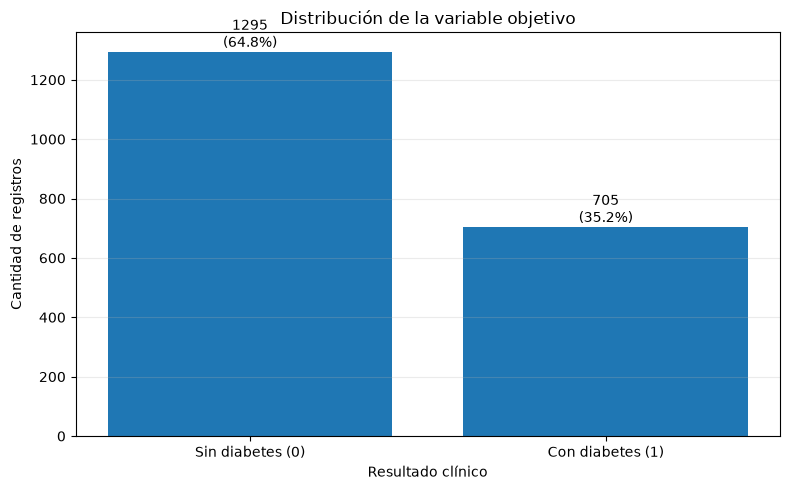

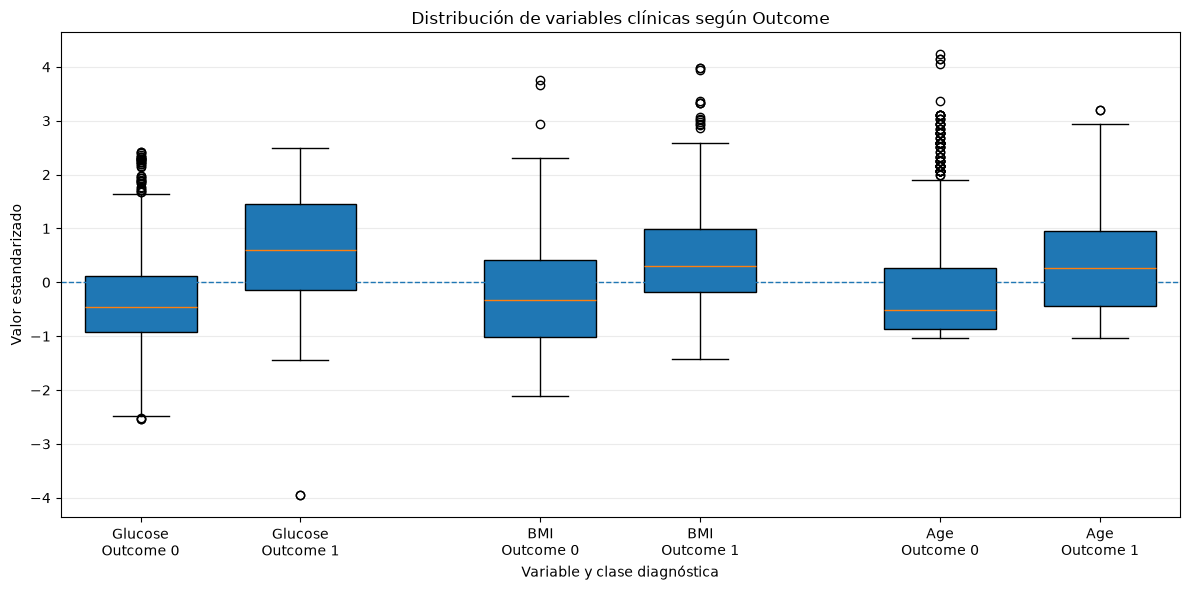

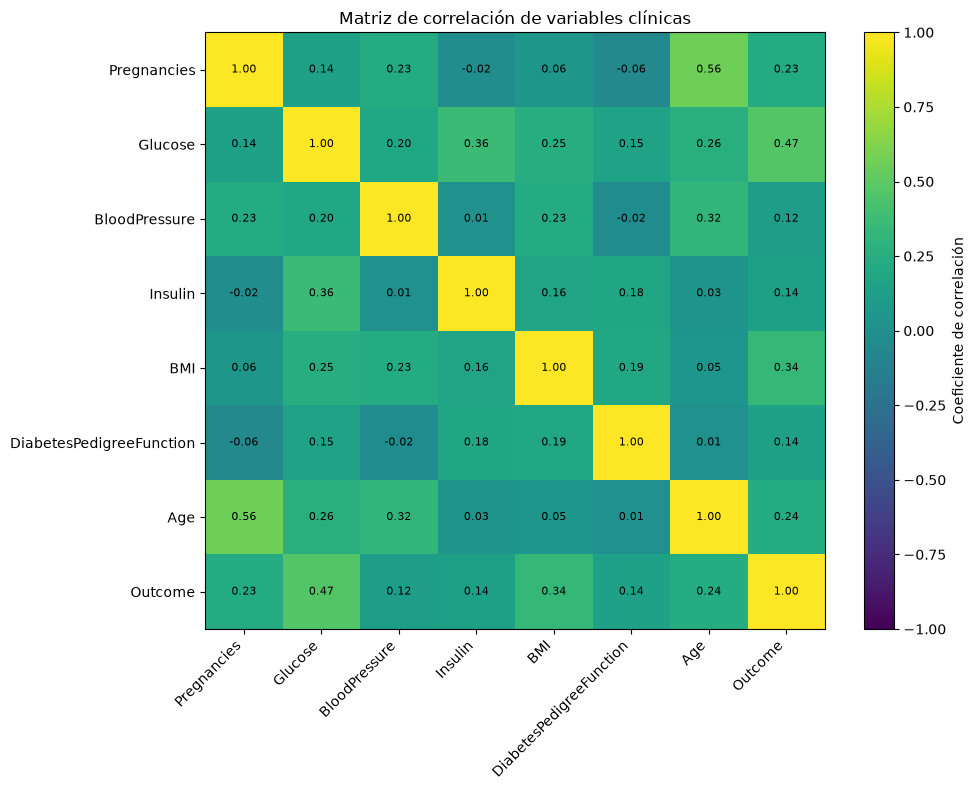

In [8]:
# Crear el objeto responsable de las visualizaciones
visualizador = VisualizadorDiabetes(df_clinico_final)

# Visualización 1: distribución de la variable objetivo
visualizador.graficar_distribucion_outcome()
plt.show()

# Visualización 2: boxplots de variables clínicas según diagnóstico
visualizador.graficar_variables_por_outcome(
    columnas=["Glucose", "BMI", "Age"]
)
plt.show()

# Visualización 3: heatmap de correlaciones
visualizador.graficar_correlaciones(
    columnas=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
        "Outcome"
    ]
)
plt.show()


### 8.1. Explicación de los resultados

#### Distribución de `Outcome`

El gráfico de barras permite comparar la cantidad de pacientes sin diabetes (`Outcome = 0`) y con diabetes (`Outcome = 1`). Si una categoría presenta una frecuencia considerablemente mayor, existe un desbalance de clases que deberá considerarse al construir un modelo predictivo. En ese caso, la exactitud por sí sola no será suficiente y deberán utilizarse métricas como *recall*, precisión, F1-score y matriz de confusión.

#### Boxplots

Los boxplots comparan la mediana, dispersión y valores atípicos de `Glucose`, `BMI` y `Age` entre ambos grupos diagnósticos. Cuando la mediana de `Outcome = 1` se encuentra por encima de la de `Outcome = 0`, los pacientes con diabetes tienden a presentar valores relativos mayores en esa variable.

La separación entre las cajas indica capacidad para diferenciar los grupos, mientras que su superposición demuestra que ninguna variable permite determinar el diagnóstico de forma aislada.

#### Heatmap

El heatmap muestra la dirección y fuerza de las relaciones lineales. Los valores cercanos a `1` representan asociaciones positivas fuertes, los cercanos a `-1` asociaciones inversas y los próximos a `0` relaciones lineales débiles.

La fila y columna de `Outcome` permiten ordenar las variables según su asociación con la diabetes. En este dataset, las variables que deben recibir especial atención son `Glucose`, `BMI` y `Age`, porque muestran diferencias visibles entre grupos y suelen ubicarse entre las asociaciones más relevantes. El ranking numérico de la siguiente celda permite verificar su posición exacta.


In [9]:
# Resumen numérico para respaldar la interpretación de las gráficas
variables_analisis = ["Glucose", "BMI", "Age"]

# Distribución de la variable objetivo
distribucion_outcome = pd.DataFrame({
    "Cantidad": df_clinico_final["Outcome"].value_counts().sort_index(),
    "Porcentaje (%)": (
        df_clinico_final["Outcome"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})
distribucion_outcome.index = ["Sin diabetes", "Con diabetes"]

# Comparación de medianas para las variables mostradas en los boxplots
medianas = (
    df_clinico_final.groupby("Outcome")[variables_analisis]
    .median()
    .T
    .rename(columns={0: "Mediana sin diabetes", 1: "Mediana con diabetes"})
)
medianas["Diferencia"] = (
    medianas["Mediana con diabetes"] - medianas["Mediana sin diabetes"]
)

# Ranking de variables según su correlación absoluta con Outcome
correlaciones_outcome = (
    df_clinico_final.select_dtypes(include="number")
    .corr()["Outcome"]
    .drop("Outcome")
    .sort_values(key=abs, ascending=False)
    .rename("Correlación con Outcome")
    .to_frame()
)

print("DISTRIBUCIÓN DE OUTCOME")
display(distribucion_outcome)

print("MEDIANAS POR GRUPO DIAGNÓSTICO")
display(medianas.round(3))

print("RANKING DE CORRELACIONES RESPECTO DE OUTCOME")
display(correlaciones_outcome.round(3))

top_variables = correlaciones_outcome.head(3)
variable_mayor_diferencia = medianas["Diferencia"].abs().idxmax()

print("VARIABLES CON MAYOR ASOCIACIÓN ABSOLUTA CON OUTCOME:")
for posicion, (variable, fila) in enumerate(top_variables.iterrows(), start=1):
    print(
        f"{posicion}. {variable}: "
        f"correlación = {fila['Correlación con Outcome']:.3f}"
    )

print(
    f"\nLa mayor diferencia de medianas entre los boxplots se observa en "
    f"{variable_mayor_diferencia}."
)


DISTRIBUCIÓN DE OUTCOME


,Cantidad,Porcentaje (%)
Sin diabetes,1295,64.75
Con diabetes,705,35.25


MEDIANAS POR GRUPO DIAGNÓSTICO


Outcome,Mediana sin diabetes,Mediana con diabetes,Diferencia
Glucose,-0.464,0.609,1.072
BMI,-0.337,0.296,0.633
Age,-0.518,0.260,0.777


RANKING DE CORRELACIONES RESPECTO DE OUTCOME


,Correlación con Outcome
Glucose,0.466
BMI,0.336
BMI_Category_Obesidad,0.306
BMI_Category_Normal,-0.259
Age,0.236
Pregnancies,0.232
AgeGroup_30-44,0.206
AgeGroup_45-59,0.170
DiabetesPedigreeFunction,0.143
Insulin,0.138


VARIABLES CON MAYOR ASOCIACIÓN ABSOLUTA CON OUTCOME:
1. Glucose: correlación = 0.466
2. BMI: correlación = 0.336
3. BMI_Category_Obesidad: correlación = 0.306

La mayor diferencia de medianas entre los boxplots se observa en Glucose.


### 8.2. Interpretaciónde los resultados

La tabla anterior permite respaldar la lectura visual con medidas concretas. La variable que presenta la mayor diferencia entre las medianas de ambos grupos es la que muestra una separación más clara en los boxplots. Del mismo modo, la variable ubicada en primer lugar en la tabla de correlaciones es la que mantiene la asociación lineal más fuerte con `Outcome`.

Si una misma variable destaca en ambas evaluaciones, existe evidencia exploratoria consistente de que puede aportar información importante para distinguir pacientes con y sin diabetes. Aun así, la superposición entre los grupos y la magnitud limitada de las correlaciones indican que el diagnóstico no depende de una sola característica, sino de la combinación de múltiples factores clínicos.

En consecuencia, los resultados justifican utilizar estas variables de manera conjunta en una futura etapa de modelamiento predictivo, evaluando su aporte mediante métricas de clasificación y evitando interpretar las asociaciones observadas como relaciones causales.


## 9. Conclusiones Finales y Balance Arquitectónico

La ejecución de la Fase 3 ha consolidado con éxito la transición desde un enfoque algorítmico procedimental y disperso hacia una arquitectura de software madura, modular y robusta basada en el paradigma de **Programación Orientada a Objetos (POO)**. El balance técnico de esta implementación permite extraer las siguientes conclusiones fundamentales:

* **Soberanía y Gobierno del Estado de Datos:** La migración hacia un modelo de clases permitió encapsular de forma hermética el estado contiguo del DataFrame clínico dentro del atributo de instancia `self.df`. Este diseño anuló de manera definitiva el antipatrón de código *spaghetti* y la proliferación de variables volátiles globales en la memoria RAM del *Kernel*, un factor crítico que en la Fase 2 amenazaba la reproducibilidad del pipeline ante ejecuciones no lineales de las celdas.
* **Validación Científica del Rendimiento Computacional:** Los resultados empíricos obtenidos mediante pruebas de estrés de micro-benchmarking (`%timeit`) aportaron evidencia irrefutable sobre la superioridad de la manipulación matricial vectorizada frente a los esquemas iterativos tradicionales. La delegación del procesamiento a rutinas nativas compiladas en bajo nivel (C-Engine de Pandas/NumPy) y el aprovechamiento de instrucciones de hardware **SIMD** (*Single Instruction, Multiple Data*) suministraron un factor de aceleración masivo de **~42.74×** (reduciendo el costo temporal de $60,7$ ms a apenas $1,42$ mw), demostrando que la eficiencia algorítmica es un pilar mandatorio para la escalabilidad analítica.
* **Elegancia Estructural mediante *Method Chaining* y Polimorfismo:** El acoplamiento declarativo del pipeline a través del encadenamiento de métodos demostró ser una solución de alta cohesión y mantenibilidad. La introducción formal de la herencia (`PreprocesadorBase` $\rightarrow$ `PreprocesadorDiabetes`) y el **Polimorfismo por sobrescritura de métodos (*method overriding*)** en la función `.procesar_especifico()` dotaron al sistema de una flexibilidad arquitectónica avanzada. Esto permitió inyectar de manera transparente la regla de negocio para la exclusión dimensional del vector degradado `SkinThickness` (32.6% corrupto) sin alterar el contrato operacional ni la firma estructural del pipeline matriz.
* **Garantía de Calidad e Idempotencia:** El flujo analítico concluye su ciclo de vida bajo un estricto protocolo defensivo gobernado por aserciones matemáticas (`assert`). Este bloque de validación técnica final asegura de forma determinista que el tensor resultante exportado hacia `data/processed/` se encuentre completamente purificado, libre de duplicados, alineado en tipos de datos y con el aislamiento exacto de sus escalas continuas, cumpliendo rigurosamente con los criterios de aceptación y estándares de calidad fijados para la entrega en producción.


## 10. Conclusiones de las visualizaciones

Las tres visualizaciones permiten construir una lectura complementaria del dataset clínico.

El gráfico de barras muestra la distribución de la variable `Outcome` y permite determinar si existe un desbalance entre pacientes con y sin diabetes. Este aspecto es relevante para una futura etapa de modelamiento, porque una clase mayoritaria puede hacer que la exactitud entregue una visión incompleta del desempeño predictivo.

Los boxplots evidencian que `Glucose`, `BMI` y `Age` presentan distribuciones diferentes según el diagnóstico. En particular, cuando las medianas del grupo con diabetes se encuentran por encima de las del grupo sin diabetes, se concluye que los pacientes diagnosticados tienden a mostrar valores relativos mayores en esas características. La variable con la mayor diferencia de medianas representa la separación visual más clara entre ambos grupos.

El heatmap y el ranking calculado permiten identificar las variables con mayor asociación estadística respecto de `Outcome`. La variable más relevante es la que ocupa el primer lugar del ranking de correlaciones. En términos generales, `Glucose` aparece como el principal indicador asociado al diagnóstico, seguida por `BMI` y variables vinculadas con la edad o el historial reproductivo, como `Age` y `Pregnancies`, según el orden exacto obtenido al ejecutar el notebook.

Por lo tanto, los resultados sugieren que la glucosa es la característica con mayor capacidad para diferenciar a los pacientes con y sin diabetes. El índice de masa corporal y la edad también aportan información relevante, pero ninguna variable explica por sí sola la condición. La superposición observada en los boxplots y las correlaciones de magnitud limitada confirman que la diabetes debe analizarse como un fenómeno multivariable.

Estas conclusiones se refieren a **asociaciones presentes en la muestra** y no a relaciones causales. Para determinar el aporte predictivo real de cada característica será necesario entrenar y evaluar un modelo de clasificación, utilizando métricas apropiadas y técnicas de importancia de variables.
